<a href="https://colab.research.google.com/github/lianafarsi/Sleep-Stress-Model/blob/main/chest_xray_explainable_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

# fix premissions, otherwise kaggle throws a security warning
!chmod 600 ~/.kaggle/kaggle.json

# pull the pneumonia dataset directly (way faster than manual upload)
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

import zipfile

# unzip the whole thing into 'chest_data' dir
with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as zip_ref:
    zip_ref.extractall('chest_data')


print("Done! Data is ready.")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:10<00:00, 226MB/s]

Done! Data is ready.


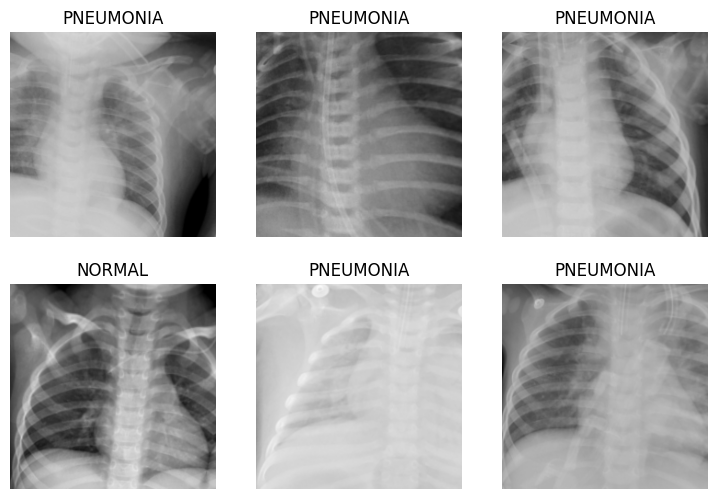

In [ ]:
from fastai.vision.all import *

path = Path('chest_data/chest_xray')

# build the dataloader: grab images , resize to 224, split into train/val, and apply basic transforms
dls = ImageDataLoaders.from_folder(
    path,
    train='train',
    valid='val',
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(mult=1.0, do_flip=False),
    bs=32
)

# peek at the data to make sure it loaded right
dls.show_batch(max_n=6)

In [ ]:
!pip install -U fastai fastcore

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.7/241.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.2/146.2 kB 16.7 MB/s eta 0:00:00
  Attempting uninstall: fastcore
    Found existing installation: fastcore 2.0.5
    Uninstalling fastcore-2.0.5:
      Successfully uninstalled fastcore-2.0.5
  Attempting uninstall: fastai
    Found existing installation: fastai 2.8.7
    Uninstalling fastai-2.8.7:
      Successfully uninstalled fastai-2.8.7


In [ ]:
# grab a standard resnet18 model and track its accuracy
learn = vision_learner(dls, resnet18, metrics=[accuracy])

# run 3 quick epochs to see how it performs
learn.fine_tune(3)

epoch,train_loss,valid_loss,accuracy,time
0,0.374050,0.193395,0.937500,01:35


epoch,train_loss,valid_loss,accuracy,time
0,0.177709,0.207244,0.875000,01:37
1,0.110754,0.182374,0.937500,01:39
2,0.071901,0.226013,0.875000,01:36


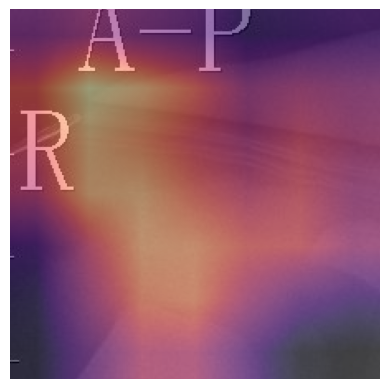

In [10]:
# grab a sample pneumonia x-ray from our validation set
img_path = get_image_files(path/'val'/'PNEUMONIA')[0]
img = PILImage.create(img_path)

# prep the image so the model can process it
batch = dls.test_dl([img])
x, = first(batch)

# peek inside the model's brain (the final conv layer) while it looks at the image
with hook_output(learn.model[0]) as hook_a:
    learn.model.eval()(x)
    # pull the activations and move to cpu for plotting
    acts = hook_a.stored[0].cpu()

# average out the layer's signals to build a 2D heatmap
heatmap = acts.mean(0)

# display the original x-ray with the heatmap glowing on top
fig, ax = plt.subplots()
img.show(ctx=ax)
ax.imshow(heatmap, alpha=0.6, extent=(0, 224, 224, 0),
          interpolation='bilinear', cmap='magma')